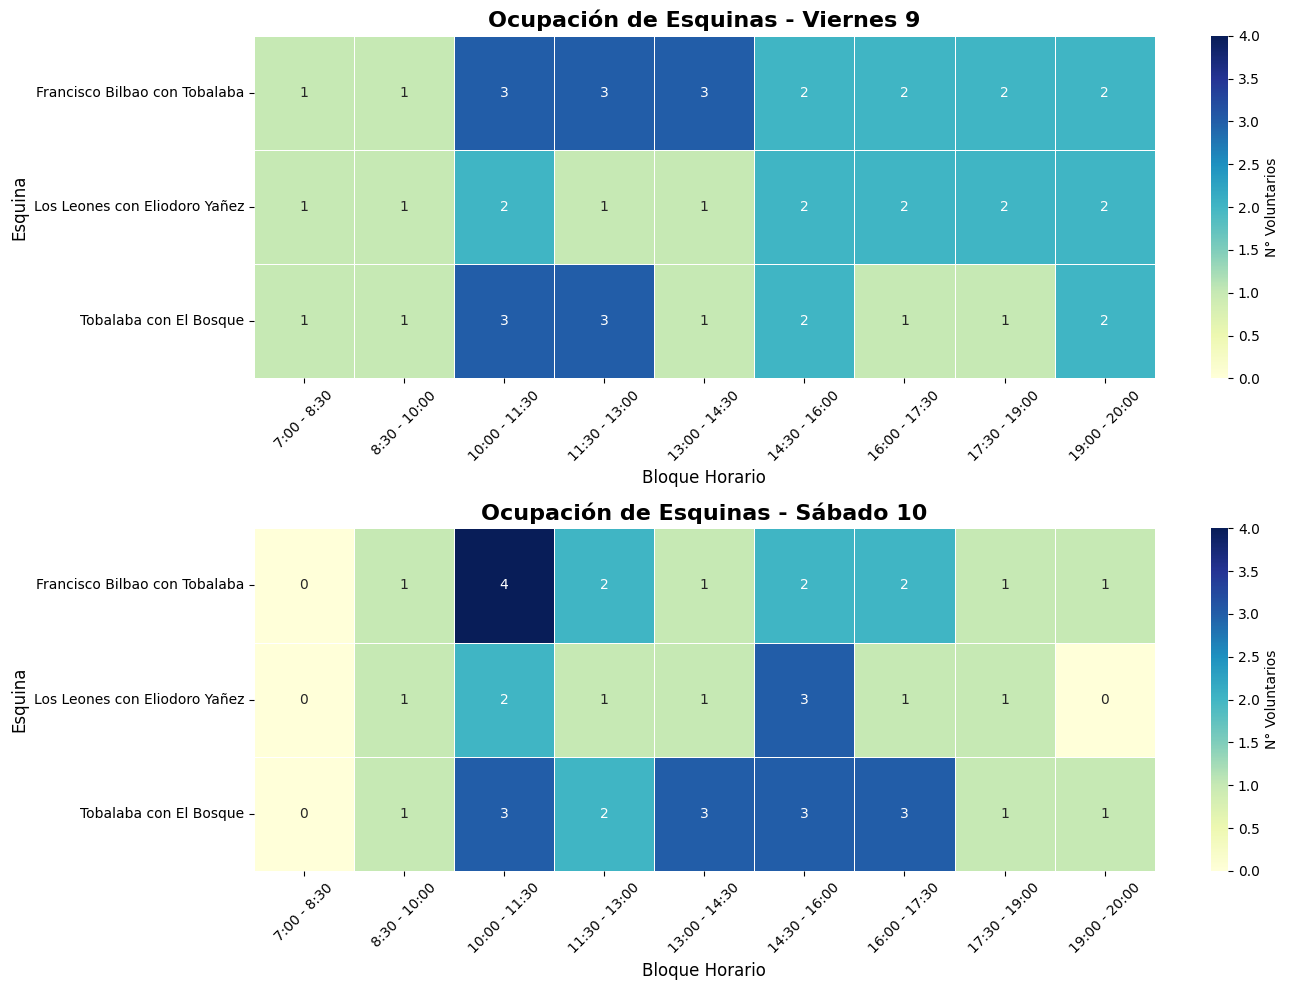

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io
import re
from pathlib import Path

# Aquí debes poner los datos del CSV que compartiste
# El notebook se ejecuta desde src/, y el CSV está en data/
project_root = Path.cwd().parent
csv_file = project_root / "data" / "assignments.csv"
csv_path = str(csv_file)
df = pd.read_csv(csv_file)

# Limpieza de espacios y saltos extraños (como los \xa0 que a veces deja Google Sheets)
df['slot'] = df['slot'].apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())
df['slot'] = df['slot'].str.replace(r'\s*-\s*', ' - ', regex=True)

# Lista con el orden estricto de los horarios
slots_order = [
    "7:00 - 8:30", "8:30 - 10:00", "10:00 - 11:30", "11:30 - 13:00",
    "13:00 - 14:30", "14:30 - 16:00", "16:00 - 17:30", "17:30 - 19:00", "19:00 - 20:00"
]

# Agrupar para contar la cantidad de voluntarios en cada cruce
counts = df.groupby(['date', 'location', 'slot']).size().reset_index(name='volunteers')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, date in enumerate(['Viernes 9', 'Sábado 10']):
    # Pivotear la tabla para convertirla en matriz
    pivot = counts[counts['date'] == date].pivot(index='location', columns='slot', values='volunteers').fillna(0)
    
    # Asegurar columnas faltantes
    for col in slots_order:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot.reindex(columns=slots_order, fill_value=0)
    
    # Dibujar el mapa de calor
    sns.heatmap(pivot, annot=True, cmap="YlGnBu", vmin=0, vmax=4, ax=axes[i], 
                linewidths=.5, cbar_kws={'label': 'N° Voluntarios'})
    axes[i].set_title(f'Ocupación de Esquinas - {date}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Bloque Horario', fontsize=12)
    axes[i].set_ylabel('Esquina', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('cronograma_visualizacion.png', dpi=300)